# 05 · Generate expression on another slice's anatomy

In this tutorial, you will use expression from DLPFC slice **151675** to generate counts at the spot locations of **151676**.
The known tissue-layer labels tell FEAST which source and target regions should correspond.

Both slices come from the same donor. This example follows the Study 05 direction **151675 → 151676**, with seed **2026**.
See [setup](README.md#setup) for the required DLPFC files.
The target's measured expression is used only afterward, to compare with the generated result.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import FEAST

TUTORIAL = Path.cwd() if Path.cwd().name == "tutorial" else Path.cwd() / "tutorial"
sys.path.insert(0, str(TUTORIAL))
from _utils import data_root, load_counts, gene_summary, gene_values, spatial_panel, cache_reference_counts
DATA = data_root()

OUT = TUTORIAL / "outputs" / "05"
OUT.mkdir(parents=True, exist_ok=True)
print("FEAST", FEAST.__version__)

FEAST 1.0.5


### 1. Describe the target without using its expression

Build a target blueprint containing spot IDs, coordinates and known layer labels.
It contains no expression counts.
A target layer is retained only if the source has at least **20 spots** with that label.
Print the retained spot count so any exclusions are visible.

For consistency with Study 05, use the genes shared by 151670, 151675 and 151676, sorted by name.
The third slice, 151670, contributes only its gene list to this example.

In [2]:
source = load_counts(DATA / "dlpfc/151675.h5ad", "ground_truth")
target_file = ad.read_h5ad(DATA / "dlpfc/151676.h5ad", backed="r")
panel_file = ad.read_h5ad(DATA / "dlpfc/151670.h5ad", backed="r")
genes = sorted(set(source.var_names) & set(target_file.var_names) & set(panel_file.var_names))
source = source[:, genes].copy()
# FEAST prefers spatial_3d when present; this tutorial explicitly uses XY.
source.obsm.pop("spatial_3d", None)
labels = target_file.obs["ground_truth"].astype(str)
support = source.obs["ground_truth"].astype(str).value_counts()
keep = labels.map(support).fillna(0).to_numpy() >= 20
ids = target_file.obs_names[keep].copy()
xy = np.asarray(target_file.obsm["spatial"])[keep, :2].copy()
obs = pd.DataFrame({"target_obs_id": ids, "ground_truth": labels.to_numpy()[keep]})
blueprint = FEAST.SliceBlueprint(coordinates=xy, domain_map=obs["ground_truth"].to_numpy(), obs=obs)
print(f"Target support: {keep.sum():,}/{len(keep):,} spots; {len(genes):,} genes")
target_file.file.close()
panel_file.file.close()

Target support: 3,431/3,431 spots; 17,391 genes


### 2. Learn from the source and generate target counts

FEAST learns expression distributions from the source, separately for each tissue layer.
It then transfers the source's spatial expression ordering to spots with the same label in the target and generates counts from the source distributions.
The gene filters below retain the shared gene panel.

We use `assignment_randomness=0.3`, the setting chosen for this Study 05 example.
This controls variation in the transferred expression pattern.
The transport solver stops with an error if it fails to converge.

`cache_reference_counts` prepares the count array once in memory so the decoder can reuse it for every gene. Count values are unchanged.

In [3]:
from FEAST.de_novo import fit_reference
fit_config = FEAST.ReferenceFitConfig(min_gene_spots=0, min_gene_mean=0.0, max_gene_zero_prop=1.0)
cache_reference_counts(source)
model = fit_reference(source, label_key="ground_truth", config=fit_config)
transport = FEAST.SimulationConfig(
    assignment_randomness=0.3, epsilon=0.05, sinkhorn_iter=1000, sinkhorn_tol=1e-5,
    unbalanced_transport=True, reg_m=5.0, transport_nonconvergence="raise",
    transport_backend="numpy", transport_dtype="float64", max_transport_pairs=25_000_000,
)
generated = FEAST.simulate(model, target=blueprint, marginal_model="empirical_reference", transport=transport, seed=2026)
assert generated.obs["target_obs_id"].tolist() == ids.tolist()
generated.obs_names = generated.obs["target_obs_id"].astype(str)
np.testing.assert_array_equal(generated.obsm["spatial"], xy)

### 3. Compare with measured target expression

After generation is complete, load the measured expression from 151676.
Plot **RELN** in the measured and generated data at the same target spots.
Both expression panels use the same `log1p` color scale, so their colors can be compared directly.

This is a focused view of one gene. Evaluating transfer more broadly requires comparisons across genes and slice pairs.

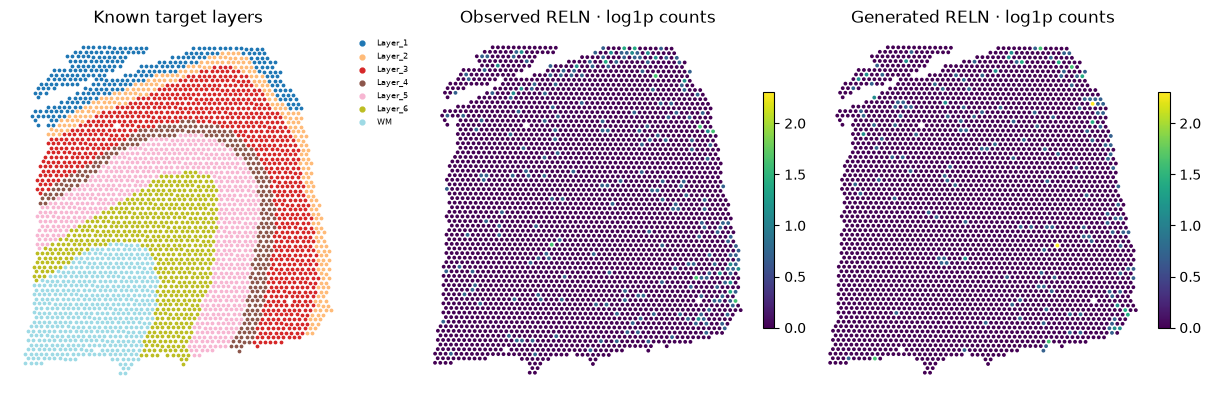

In [4]:
observed = load_counts(DATA / "dlpfc/151676.h5ad", "ground_truth")[generated.obs_names, generated.var_names].copy()
gene = "RELN"
observed_values = np.log1p(gene_values(observed, gene))
generated_values = np.log1p(gene_values(generated, gene))
limit = max(observed_values.max(), generated_values.max())
fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")
spatial_panel(axes[0], xy, generated.obs["ground_truth"], "Known target layers", True)
spatial_panel(axes[1], xy, observed_values, f"Observed {gene} · log1p counts", vmax=limit)
spatial_panel(axes[2], xy, generated_values, f"Generated {gene} · log1p counts", vmax=limit)
plt.show()
generated.write_h5ad(OUT / "151675_to_151676.h5ad")

**How to read the plots:** the first panel shows the layer labels supplied to FEAST.
The other panels compare measured and generated RELN expression within that anatomy.
The task assumes that the target's layer labels are already known.

Study 05 also includes a half-slice example: use spots with `x <= median(x)` as the source and generate expression for the other half.
Build that target from coordinates and labels only, and check source-layer support again before fitting.